# End-to-End E-commerce Intelligence System
## Building a Customer 360 Analytics Framework

**Objective:** Integrate multiple e-commerce data sources, construct a unified Customer 360 view, analyze customer behavior, revenue patterns, and operational performance, and generate actionable business recommendations.

---
## Step 1: Data Loading and Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

DATA_PATH = 'dataset/'

In [2]:
# Load all datasets
customers   = pd.read_csv(DATA_PATH + 'customers.csv')
orders      = pd.read_csv(DATA_PATH + 'orders.csv')
order_items = pd.read_csv(DATA_PATH + 'order_item.csv')
payments    = pd.read_csv(DATA_PATH + 'payments.csv')
reviews     = pd.read_csv(DATA_PATH + 'reviews.csv')
products    = pd.read_csv(DATA_PATH + 'products.csv')
sellers     = pd.read_csv(DATA_PATH + 'sellers.csv')
cat_trans   = pd.read_csv(DATA_PATH + 'category_translation.csv')

# location.csv has 1M+ rows — load a sample for display only (not used in analysis)
location = pd.read_csv(DATA_PATH + 'location.csv', nrows=5000)

print('All datasets loaded successfully!')

All datasets loaded successfully!


In [3]:
# Dataset shapes overview
datasets = {
    'customers'  : customers,
    'orders'     : orders,
    'order_items': order_items,
    'payments'   : payments,
    'reviews'    : reviews,
    'products'   : products,
    'sellers'    : sellers,
    'location'   : location,
    'cat_trans'  : cat_trans
}

for name, df in datasets.items():
    print(f'{name:15s} -> Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

customers       -> Rows: 99441  |  Columns: 5
orders          -> Rows: 99441  |  Columns: 8
order_items     -> Rows: 112650  |  Columns: 7
payments        -> Rows: 103886  |  Columns: 5
reviews         -> Rows: 99224  |  Columns: 7
products        -> Rows: 32951  |  Columns: 9
sellers         -> Rows: 3095  |  Columns: 4
location        -> Rows: 5000  |  Columns: 5
cat_trans       -> Rows: 71  |  Columns: 2


In [4]:
# Preview each table
for name, df in datasets.items():
    print(f'\n=== {name.upper()} ===')
    display(df.head(3))


=== CUSTOMERS ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



=== ORDERS ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



=== ORDER_ITEMS ===


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



=== LOCATION ===


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



=== CAT_TRANS ===


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [5]:
# Data types and null summary
for name, df in datasets.items():
    print(f'\n=== {name.upper()} - Info ===')
    print(df.dtypes)
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print('\nMissing values:')
        print(nulls[nulls > 0])


=== CUSTOMERS - Info ===
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

=== ORDERS - Info ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

=== ORDER_ITEMS - Info ===
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

=== PAYMENTS - Info ===


In [6]:
# Primary and foreign key relationships
print('PRIMARY KEYS (unique identifiers per table):')
print(f"  customers   -> customer_id      unique: {customers['customer_id'].nunique()}")
print(f"  orders      -> order_id         unique: {orders['order_id'].nunique()}")
print(f"  products    -> product_id       unique: {products['product_id'].nunique()}")
print(f"  sellers     -> seller_id        unique: {sellers['seller_id'].nunique()}")
print()
print('FOREIGN KEY LINKS:')
print('  orders.customer_id      -> customers.customer_id')
print('  order_items.order_id    -> orders.order_id')
print('  order_items.product_id  -> products.product_id')
print('  order_items.seller_id   -> sellers.seller_id')
print('  payments.order_id       -> orders.order_id')
print('  reviews.order_id        -> orders.order_id')
print('  products.category_name  -> cat_trans.product_category_name')

PRIMARY KEYS (unique identifiers per table):
  customers   -> customer_id      unique: 99441
  orders      -> order_id         unique: 99441
  products    -> product_id       unique: 32951
  sellers     -> seller_id        unique: 3095

FOREIGN KEY LINKS:
  orders.customer_id      -> customers.customer_id
  order_items.order_id    -> orders.order_id
  order_items.product_id  -> products.product_id
  order_items.seller_id   -> sellers.seller_id
  payments.order_id       -> orders.order_id
  reviews.order_id        -> orders.order_id
  products.category_name  -> cat_trans.product_category_name


---
## Step 2: Data Cleaning and Preprocessing

In [7]:
# Convert date columns in orders to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Convert date columns in reviews
reviews['review_creation_date']   = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

# Convert date in order_items
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

print('Date columns converted successfully.')

Date columns converted successfully.


In [8]:
# Standardize column names (lowercase + strip spaces)
for name in datasets:
    datasets[name].columns = datasets[name].columns.str.strip().str.lower()

# Re-assign after column rename
customers   = datasets['customers']
orders      = datasets['orders']
order_items = datasets['order_items']
payments    = datasets['payments']
reviews     = datasets['reviews']
products    = datasets['products']
sellers     = datasets['sellers']
location    = datasets['location']
cat_trans   = datasets['cat_trans']

print('Column names standardized.')

Column names standardized.


In [9]:
# Remove duplicate records
for name, df in datasets.items():
    before = len(df)
    df.drop_duplicates(inplace=True)
    after = len(df)
    if before != after:
        print(f'{name}: removed {before - after} duplicates')
    else:
        print(f'{name}: no duplicates found')

customers: no duplicates found
orders: no duplicates found
order_items: no duplicates found
payments: no duplicates found
reviews: no duplicates found
products: no duplicates found
sellers: no duplicates found
location: removed 2146 duplicates
cat_trans: no duplicates found


In [10]:
# Handle missing values

# orders: rows with missing delivery dates are likely still in-transit - keep them
# For analysis we filter to 'delivered' orders only when needed
print('Orders status distribution:')
print(orders['order_status'].value_counts())

# reviews: fill missing comment fields with empty string
reviews['review_comment_title']   = reviews['review_comment_title'].fillna('')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('')

# products: fill missing category with 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# payments: check for nulls
print('\nPayments null check:')
print(payments.isnull().sum())

print('\nMissing values handled.')

Orders status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Payments null check:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Missing values handled.


In [11]:
# Validate numeric ranges
print('Order items - price stats:')
print(order_items[['price', 'freight_value']].describe())

print('\nPayments - payment_value stats:')
print(payments['payment_value'].describe())

print('\nReview scores distribution:')
print(reviews['review_score'].value_counts().sort_index())

Order items - price stats:
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000

Payments - payment_value stats:
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Review scores distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


---
## Step 3: Data Integration — Building the Master Dataset

In [12]:
# 3.1 orders + customers
df = orders.merge(customers, on='customer_id', how='left')
print(f'orders + customers: {df.shape}')

orders + customers: (99441, 12)


In [13]:
# 3.2 + order_items
df = df.merge(order_items, on='order_id', how='left')
print(f'+ order_items: {df.shape}')

+ order_items: (113425, 18)


In [14]:
# 3.3 + products + category translation
products_en = products.merge(cat_trans, on='product_category_name', how='left')
products_en['product_category_name_english'] = products_en['product_category_name_english'].fillna('unknown')

df = df.merge(products_en[['product_id', 'product_category_name', 'product_category_name_english',
                             'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']],
              on='product_id', how='left')
print(f'+ products & category translation: {df.shape}')

+ products & category translation: (113425, 24)


In [15]:
# 3.4 + sellers
df = df.merge(sellers[['seller_id', 'seller_city', 'seller_state']], on='seller_id', how='left')
print(f'+ sellers: {df.shape}')

+ sellers: (113425, 26)


In [16]:
# 3.5 + payments (aggregate per order to avoid row explosion)
payments_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_type=('payment_type', lambda x: x.mode()[0]),
    payment_installments=('payment_installments', 'max')
).reset_index()
#print(payments_agg)
df = df.merge(payments_agg, on='order_id', how='left')
print(f'+ payments: {df.shape}')

+ payments: (113425, 29)


In [17]:
# 3.6 + reviews (keep most recent/first review per order)
reviews_agg = reviews.sort_values('review_creation_date').groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

df = df.merge(reviews_agg, on='order_id', how='left')
print(f'+ reviews: {df.shape}')
print('\nMaster dataset columns:')
print(df.columns.tolist())

+ reviews: (113425, 30)

Master dataset columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_category_name_english', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_city', 'seller_state', 'payment_value', 'payment_type', 'payment_installments', 'review_score']


In [18]:
print('Master Dataset Shape:', df.shape)
display(df.head())

Master Dataset Shape: (113425, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state,payment_value,payment_type,payment_installments,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,500.0,19.0,8.0,13.0,maua,SP,38.71,voucher,1.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,400.0,19.0,13.0,19.0,belo horizonte,SP,141.46,boleto,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,420.0,24.0,19.0,21.0,guariba,SP,179.12,credit_card,3.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,450.0,30.0,10.0,20.0,belo horizonte,MG,72.20,credit_card,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,250.0,51.0,15.0,15.0,mogi das cruzes,SP,28.62,credit_card,1.0,5.0


---
## Step 4: Feature Engineering

In [19]:
# Work on delivered orders for time-based features
delivered = df[df['order_status'] == 'delivered'].copy()

# 4.1 Delivery time (days from purchase to customer delivery)
delivered['delivery_time_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

# 4.2 Estimated vs actual delivery difference (negative = early)
delivered['delivery_delay_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']
).dt.days

# 4.3 Order month and year
delivered['order_year']  = delivered['order_purchase_timestamp'].dt.year
delivered['order_month'] = delivered['order_purchase_timestamp'].dt.month
delivered['order_yearmonth'] = delivered['order_purchase_timestamp'].dt.to_period('M')

# 4.4 Total item value per order row
delivered['item_total_value'] = delivered['price'] + delivered['freight_value']
print('Basic features created.')
print(delivered[['delivery_time_days', 'delivery_delay_days', 'item_total_value']].describe())

Basic features created.
       delivery_time_days  delivery_delay_days  item_total_value
count       110189.000000        110189.000000     110197.000000
mean            12.007342           -12.029041        139.929161
std              9.451153            10.158194        189.319151
min              0.000000          -147.000000          6.080000
25%              6.000000           -17.000000         55.180000
50%             10.000000           -13.000000         92.130000
75%             15.000000            -7.000000        157.510000
max            209.000000           188.000000       6929.310000


In [20]:
# 4.5 Order-level aggregations
order_agg = delivered.groupby('order_id').agg(
    total_order_value=('item_total_value', 'sum'),
    num_items=('order_item_id', 'count'),
    delivery_time_days=('delivery_time_days', 'first'),
    delivery_delay_days=('delivery_delay_days', 'first'),
    review_score=('review_score', 'first'),
    customer_id=('customer_id', 'first'),
    customer_state=('customer_state', 'first'),
    order_yearmonth=('order_yearmonth', 'first'),
    payment_type=('payment_type', 'first')
).reset_index()

print('Order-level aggregations:')
display(order_agg.head())

Order-level aggregations:


,order_id,total_order_value,num_items,delivery_time_days,delivery_delay_days,review_score,customer_id,customer_state,order_yearmonth,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,7.0,-9.0,5.0,3ce436f183e68e07877b285a838db11a,RJ,2017-09,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,16.0,-3.0,4.0,f6dd3ec061db4e3987629fe6b26e5cce,SP,2017-04,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,1,7.0,-14.0,5.0,6489ae5e4333f3693df5ad4372dab6d3,MG,2018-01,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,6.0,-6.0,4.0,d4eb9395c8c0431ee92fce09860c5a06,SP,2018-08,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,25.0,-16.0,5.0,58dbd0b2d70206bf40e62cd34e84d795,SP,2017-02,credit_card


In [21]:
# 4.6 Customer-level features (Customer 360)
customer_360 = order_agg.groupby('customer_id').agg(
    purchase_frequency=('order_id', 'count'),
    total_lifetime_value=('total_order_value', 'sum'),
    avg_order_value=('total_order_value', 'mean'),
    avg_review_score=('review_score', 'mean'),
    avg_delivery_days=('delivery_time_days', 'mean'),
    customer_state=('customer_state', 'first')
).reset_index()

# Segment customers by value
clv_33 = customer_360['total_lifetime_value'].quantile(0.33)
clv_66 = customer_360['total_lifetime_value'].quantile(0.66)

def segment_customer(val):
    if val <= clv_33:
        return 'Low Value'
    elif val <= clv_66:
        return 'Mid Value'
    else:
        return 'High Value'

customer_360['customer_segment'] = customer_360['total_lifetime_value'].apply(segment_customer)

# New vs repeat customers
customer_360['customer_type'] = customer_360['purchase_frequency'].apply(
    lambda x: 'Repeat' if x > 1 else 'New'
)

print('Customer 360 View:')
display(customer_360.head())
print(f'\nTotal unique customers: {len(customer_360):,}')

Customer 360 View:


,customer_id,purchase_frequency,total_lifetime_value,avg_order_value,avg_review_score,avg_delivery_days,customer_state,customer_segment,customer_type
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,114.74,1.0,13.0,SP,Mid Value,New
1,000161a058600d5901f007fab4c27140,1,67.41,67.41,4.0,9.0,MG,Low Value,New
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,195.42,5.0,5.0,ES,High Value,New
3,0002414f95344307404f0ace7a26f1d5,1,179.35,179.35,5.0,28.0,MG,High Value,New
4,000379cdec625522490c315e70c7a9fb,1,107.01,107.01,4.0,11.0,SP,Mid Value,New



Total unique customers: 96,478


---
## Step 5: Exploratory Data Analysis (EDA)

### 5.1 Customer Analysis

In [22]:
# New vs Repeat customers
ctype_counts = customer_360['customer_type'].value_counts()
print('Customer Type Distribution:')
print(ctype_counts)
print(f'\nRepeat customer rate: {ctype_counts.get("Repeat", 0) / len(customer_360) * 100:.1f}%')

Customer Type Distribution:
customer_type
New    96478
Name: count, dtype: int64

Repeat customer rate: 0.0%


In [23]:
# Customer value segment distribution
seg_counts = customer_360['customer_segment'].value_counts()
print('Customer Segment Distribution:')
print(seg_counts)

# CLV stats by segment
print('\nAverage CLV by Segment:')
print(customer_360.groupby('customer_segment')['total_lifetime_value'].mean().round(2))

Customer Segment Distribution:
customer_segment
High Value    32803
Low Value     31849
Mid Value     31826
Name: count, dtype: int64

Average CLV by Segment:
customer_segment
High Value    320.19
Low Value      48.84
Mid Value     105.61
Name: total_lifetime_value, dtype: float64


In [24]:
# Top 10 states by customer count
top_states = customer_360['customer_state'].value_counts().head(10)
print('Top 10 States by Customer Count:')
print(top_states)

Top 10 States by Customer Count:
customer_state
SP    40501
RJ    12350
MG    11354
RS     5345
PR     4923
SC     3546
BA     3256
DF     2080
ES     1995
GO     1957
Name: count, dtype: int64


### 5.2 Revenue and Order Analysis

In [25]:
# Monthly revenue trend
monthly_revenue = order_agg.groupby('order_yearmonth')['total_order_value'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']
monthly_revenue = monthly_revenue.sort_values('month')
print('Monthly Revenue Summary:')
print(monthly_revenue.tail(10))

Monthly Revenue Summary:
      month     revenue
13  2017-11  1153364.20
14  2017-12   843078.29
15  2018-01  1077887.46
16  2018-02   966168.41
17  2018-03  1120598.24
18  2018-04  1132878.93
19  2018-05  1128774.52
20  2018-06  1011978.29
21  2018-07  1027807.28
22  2018-08   985491.64


In [26]:
# Monthly order volume
monthly_orders = order_agg.groupby('order_yearmonth')['order_id'].count().reset_index()
monthly_orders.columns = ['month', 'order_count']
monthly_orders = monthly_orders.sort_values('month')

print(f'Total Revenue: R$ {order_agg["total_order_value"].sum():,.2f}')
print(f'Total Orders: {len(order_agg):,}')
print(f'Average Order Value: R$ {order_agg["total_order_value"].mean():,.2f}')

Total Revenue: R$ 15,419,773.75
Total Orders: 96,478
Average Order Value: R$ 159.83


In [27]:
# Payment type distribution
print('Payment Type Distribution:')
print(order_agg['payment_type'].value_counts())

Payment Type Distribution:
payment_type
credit_card    73941
boleto         19191
voucher         1861
debit_card      1484
Name: count, dtype: int64


### 5.3 Product Analysis

In [28]:
# Top categories by revenue
category_revenue = delivered.groupby('product_category_name_english').agg(
    revenue=('item_total_value', 'sum'),
    order_count=('order_id', 'nunique')
).sort_values('revenue', ascending=False).reset_index()

print('Top 10 Categories by Revenue:')
display(category_revenue.head(10))

Top 10 Categories by Revenue:


,product_category_name_english,revenue,order_count
0,health_beauty,1412089.53,8647
1,watches_gifts,1264333.12,5495
2,bed_bath_table,1225209.26,9272
3,sports_leisure,1118256.91,7530
4,computers_accessories,1032723.77,6530
5,furniture_decor,880329.92,6307
6,housewares,758392.25,5743
7,cool_stuff,691680.89,3559
8,auto,669454.75,3810
9,garden_tools,567145.68,3448


### 5.4 Seller Analysis

In [29]:
# Top 10 sellers by revenue
seller_revenue = delivered.groupby('seller_id').agg(
    revenue=('item_total_value', 'sum'),
    order_count=('order_id', 'nunique')
).sort_values('revenue', ascending=False).reset_index()

print('Top 10 Sellers by Revenue:')
display(seller_revenue.head(10))

print(f'\nTotal sellers: {len(seller_revenue):,}')
top10_share = seller_revenue.head(10)['revenue'].sum() / seller_revenue['revenue'].sum() * 100
print(f'Top 10 sellers revenue share: {top10_share:.1f}%')

Top 10 Sellers by Revenue:


,seller_id,revenue,order_count
0,4869f7a5dfa277a7dca6462dcf3b52b2,247007.06,1124
1,7c67e1448b00f6e969d365cea6b010ab,237806.69,973
2,4a3ca9315b744ce9f8e9374361493884,231220.43,1772
3,53243585a1d6dc2643021fd1853d8905,230797.02,348
4,fa1c13f2614d7b5c4749cbc52fecda94,200833.50,578
5,da8622b14eb17ae2831f4ac5b9dab84a,184706.78,1311
6,7e93a43ef30c4f03f38b393420bc753a,171973.55,319
7,1025f0e2d44d7041d6cf58b6550e0bfa,171924.96,910
8,7a67c85e85bb2ce8582c35f2203ad736,160278.52,1145
9,955fee9216a65b617aa5c0531780ce60,156606.48,1261



Total sellers: 2,970
Top 10 sellers revenue share: 12.9%


### 5.5 Review and Satisfaction Analysis

In [30]:
# Review score distribution
print('Review Score Distribution:')
print(reviews['review_score'].value_counts().sort_index())

avg_score = reviews['review_score'].mean()
print(f'\nAverage Review Score: {avg_score:.2f} / 5')

Review Score Distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Average Review Score: 4.09 / 5


In [31]:
# Delivery time vs review score
review_delivery = delivered[delivered['review_score'].notna()].groupby(
    pd.cut(delivered[delivered['review_score'].notna()]['delivery_time_days'],
           bins=[0, 7, 14, 21, 30, 60, 120],
           labels=['0-7d', '8-14d', '15-21d', '22-30d', '31-60d', '60d+'])
)['review_score'].mean().reset_index()
review_delivery.columns = ['delivery_bucket', 'avg_review_score']

print('Average Review Score by Delivery Time:')
print(review_delivery)

Average Review Score by Delivery Time:
  delivery_bucket  avg_review_score
0            0-7d          4.331330
1           8-14d          4.199160
2          15-21d          4.022733
3          22-30d          3.436292
4          31-60d          2.162309
5            60d+          2.074297


In [32]:
# Dissatisfaction: orders with score <= 2
dissatisfied = order_agg[order_agg['review_score'] <= 2]
print(f'Dissatisfied orders (score <= 2): {len(dissatisfied):,} ({len(dissatisfied)/len(order_agg)*100:.1f}%)')
print(f'Avg delivery time (dissatisfied): {dissatisfied["delivery_time_days"].mean():.1f} days')
print(f'Avg delivery time (all):          {order_agg["delivery_time_days"].mean():.1f} days')

Dissatisfied orders (score <= 2): 12,237 (12.7%)
Avg delivery time (dissatisfied): 19.8 days
Avg delivery time (all):          12.1 days


---
## Step 6: Data Visualization

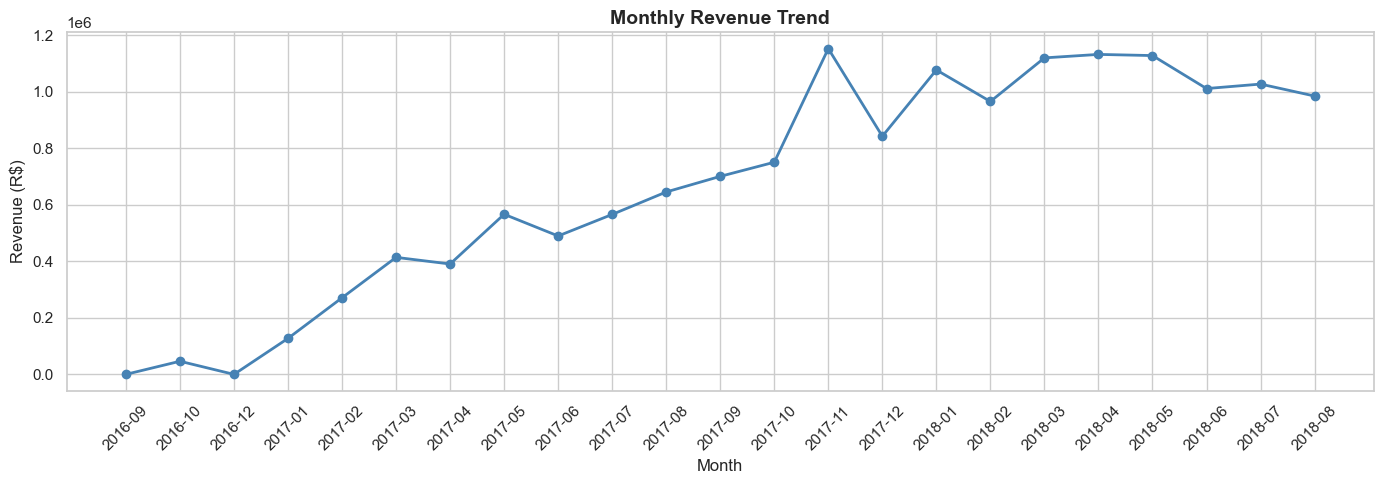

In [33]:
# 6.1 Monthly Revenue Trend (Time Series)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['month'].astype(str), monthly_revenue['revenue'], marker='o', color='steelblue', linewidth=2)
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/plot_01_monthly_revenue.png', dpi=150)
plt.show()

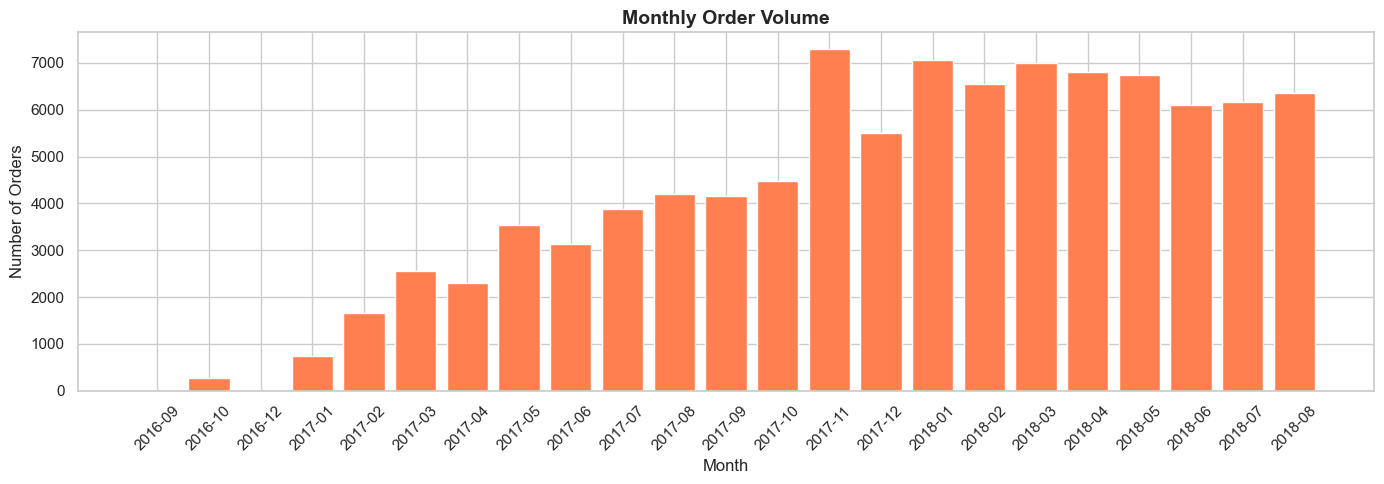

In [34]:
# 6.2 Monthly Order Volume (Time Series)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_orders['month'].astype(str), monthly_orders['order_count'], color='coral')
ax.set_title('Monthly Order Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/plot_02_monthly_orders.png', dpi=150)
plt.show()

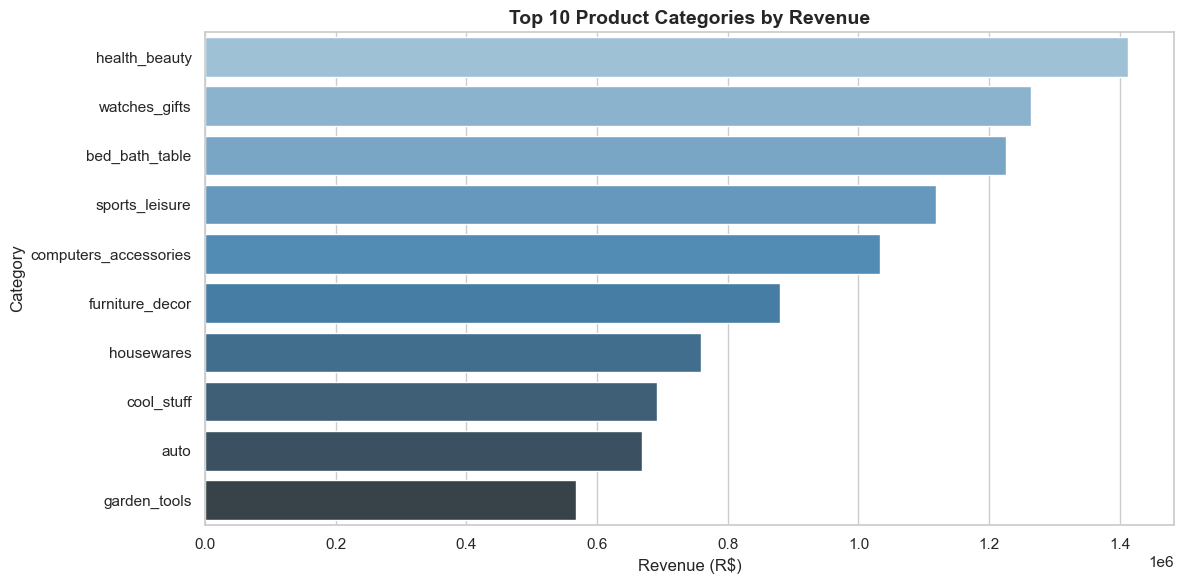

In [35]:
# 6.3 Top 10 Product Categories by Revenue (Bar Chart)
fig, ax = plt.subplots(figsize=(12, 6))
top_cats = category_revenue.head(10)
sns.barplot(data=top_cats, y='product_category_name_english', x='revenue', palette='Blues_d', ax=ax)
ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (R$)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('plots/plot_03_top_categories.png', dpi=150)
plt.show()

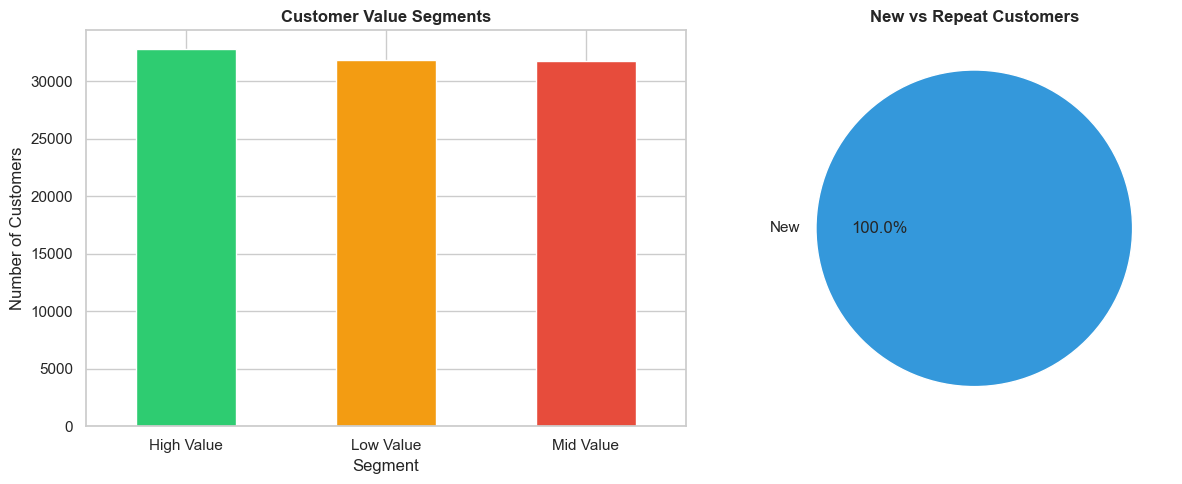

In [36]:
# 6.4 Customer Segment Distribution (Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Customer Value Segments', fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

ctype_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#3498db', '#e67e22'])
axes[1].set_title('New vs Repeat Customers', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('plots/plot_04_customer_segments.png', dpi=150)
plt.show()

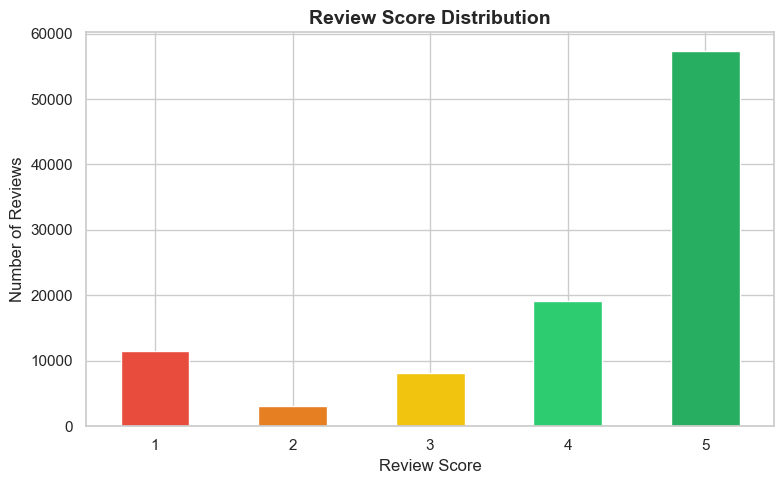

In [37]:
# 6.5 Review Score Distribution (Bar Chart)
fig, ax = plt.subplots(figsize=(8, 5))
score_counts = reviews['review_score'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
score_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Review Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Reviews')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('plots/plot_05_review_scores.png', dpi=150)
plt.show()

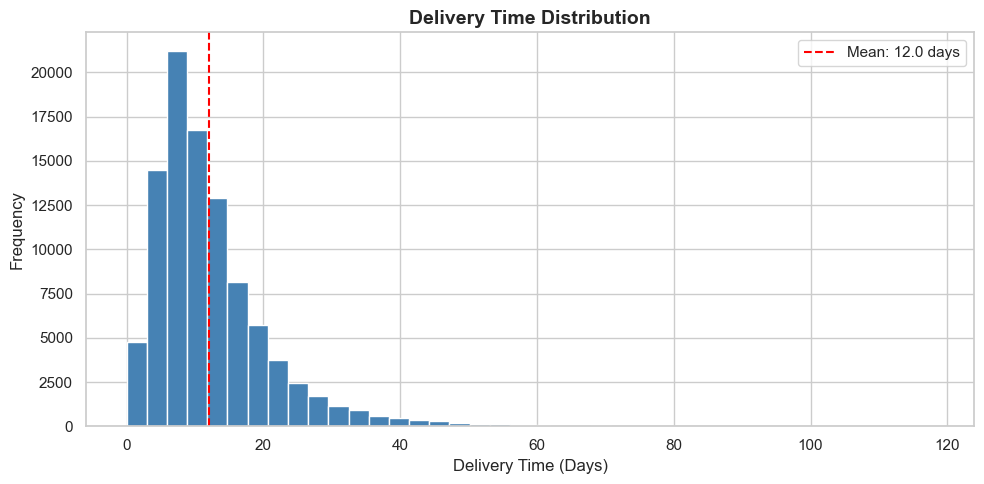

In [38]:
# 6.6 Delivery Time Distribution (Histogram)
fig, ax = plt.subplots(figsize=(10, 5))
valid_delivery = order_agg['delivery_time_days'].dropna()
valid_delivery = valid_delivery[valid_delivery.between(0, 120)]
ax.hist(valid_delivery, bins=40, color='steelblue', edgecolor='white')
ax.axvline(valid_delivery.mean(), color='red', linestyle='--', label=f'Mean: {valid_delivery.mean():.1f} days')
ax.set_title('Delivery Time Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Time (Days)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('plots/plot_06_delivery_time.png', dpi=150)
plt.show()

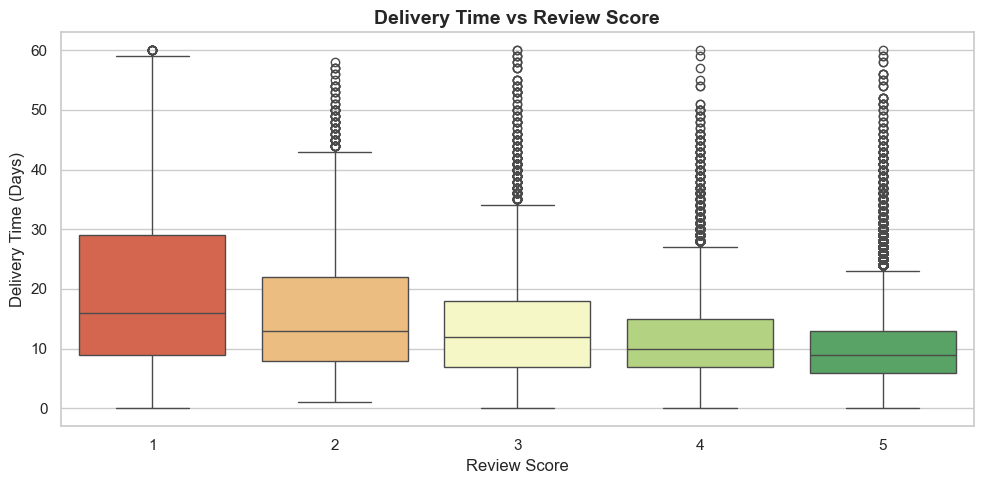

In [39]:
# 6.7 Delivery Time vs Review Score (Box Plot)
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = order_agg[order_agg['review_score'].notna() & order_agg['delivery_time_days'].between(0, 60)].copy()
plot_df['review_score'] = plot_df['review_score'].astype(int)
sns.boxplot(data=plot_df, x='review_score', y='delivery_time_days', palette='RdYlGn', ax=ax)
ax.set_title('Delivery Time vs Review Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Delivery Time (Days)')
plt.tight_layout()
plt.savefig('plots/plot_07_delivery_vs_review.png', dpi=150)
plt.show()

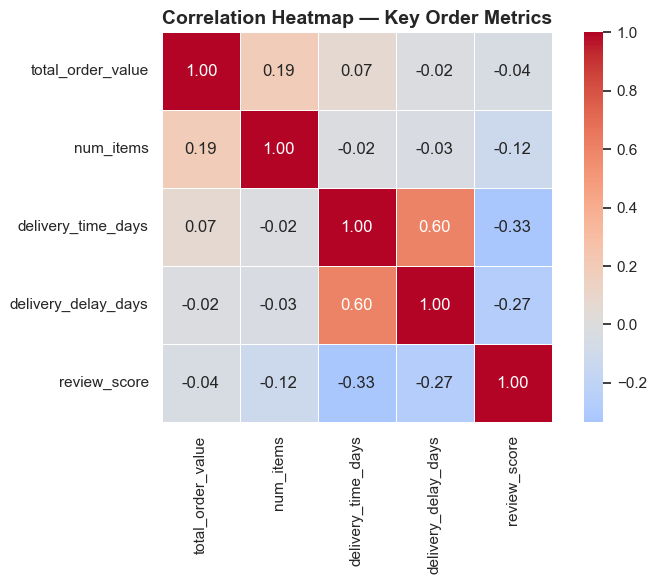

In [40]:
# 6.8 Correlation Heatmap
corr_cols = ['total_order_value', 'num_items', 'delivery_time_days', 'delivery_delay_days', 'review_score']
corr_df = order_agg[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Key Order Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/plot_08_correlation_heatmap.png', dpi=150)
plt.show()

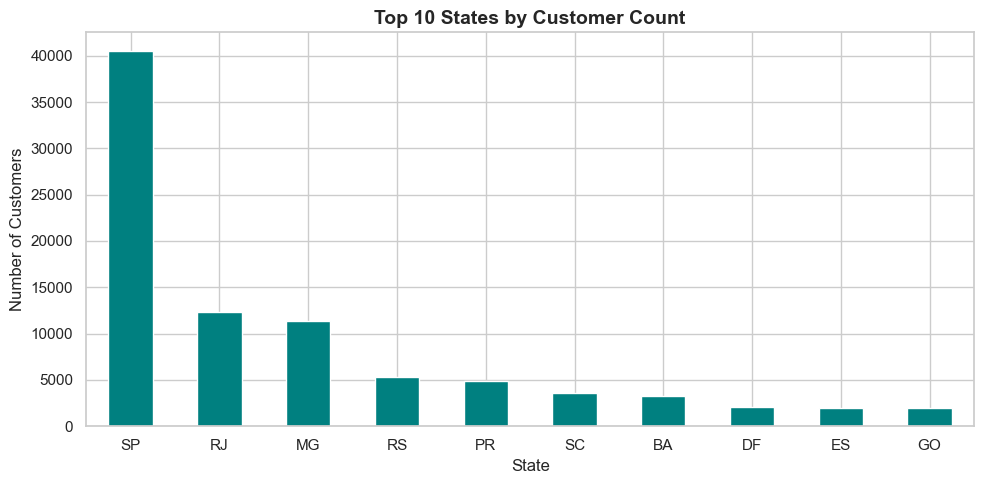

In [41]:
# 6.9 Top 10 States by Customer Count (Bar Chart)
fig, ax = plt.subplots(figsize=(10, 5))
top_states.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 10 States by Customer Count', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('plots/plot_09_top_states.png', dpi=150)
plt.show()

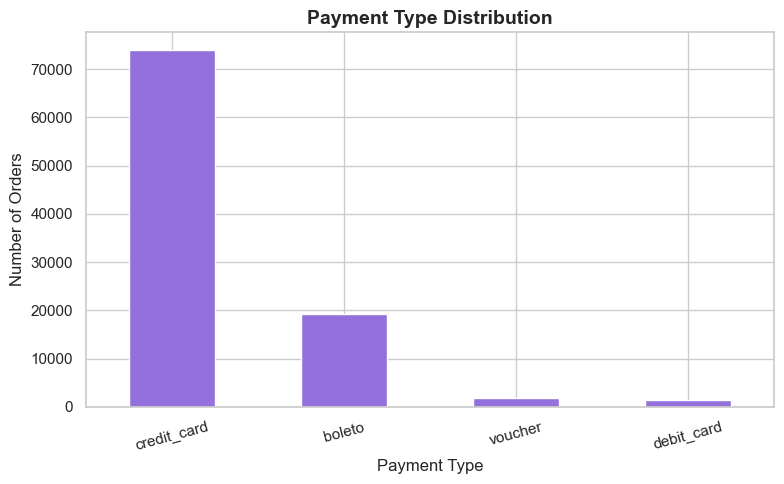

In [42]:
# 6.10 Payment Type Distribution (Bar Chart)
fig, ax = plt.subplots(figsize=(8, 5))
payment_counts = order_agg['payment_type'].value_counts()
payment_counts.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Payment Type Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('plots/plot_10_payment_types.png', dpi=150)
plt.show()

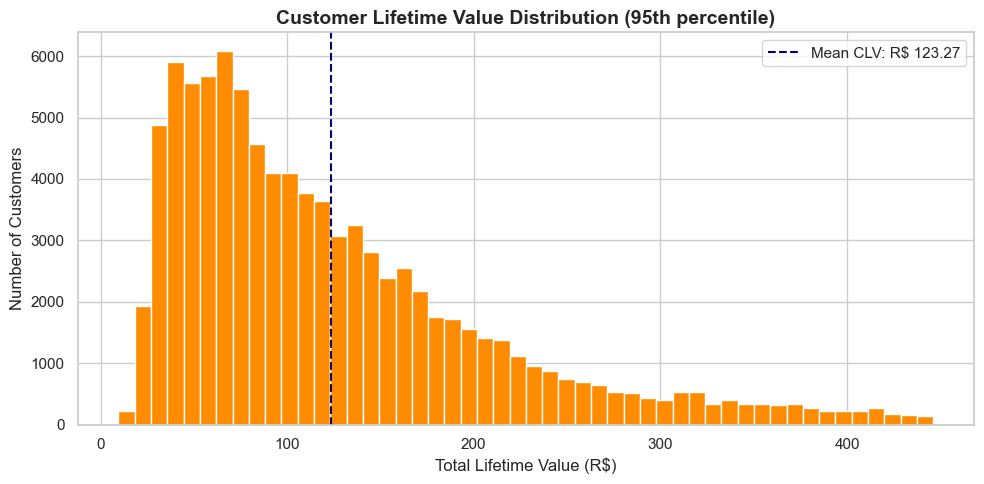

In [43]:
# 6.11 Customer Lifetime Value Distribution (Histogram with outlier trimming)
fig, ax = plt.subplots(figsize=(10, 5))
clv_data = customer_360['total_lifetime_value']
clv_data_trim = clv_data[clv_data < clv_data.quantile(0.95)]
ax.hist(clv_data_trim, bins=50, color='darkorange', edgecolor='white')
ax.axvline(clv_data_trim.mean(), color='navy', linestyle='--', label=f'Mean CLV: R$ {clv_data_trim.mean():.2f}')
ax.set_title('Customer Lifetime Value Distribution (95th percentile)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Lifetime Value (R$)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig('plots/plot_11_clv_distribution.png', dpi=150)
plt.show()

---
## Step 7: Business Insights and Recommendations

In [44]:
print('=' * 65)
print('BUSINESS INSIGHTS — E-COMMERCE INTELLIGENCE REPORT')
print('=' * 65)

print()
print('--- INSIGHT 1: Revenue Concentration ---')
top3_cats = category_revenue.head(3)
top3_share = top3_cats['revenue'].sum() / category_revenue['revenue'].sum() * 100
print(f'The top 3 product categories contribute {top3_share:.1f}% of total revenue.')
print(f'Categories: {list(top3_cats["product_category_name_english"])}')
print('RECOMMENDATION: Prioritize inventory, marketing, and seller recruitment')
print('for these categories to maintain and grow the revenue base.')

print()
print('--- INSIGHT 2: Customer Retention is Low ---')
repeat_rate = customer_360['customer_type'].value_counts(normalize=True).get('Repeat', 0) * 100
print(f'Only {repeat_rate:.1f}% of customers have placed more than one order.')
print('RECOMMENDATION: Implement loyalty programs, personalized email campaigns,')
print('and post-purchase follow-ups to improve repeat purchase rates.')

print()
print('--- INSIGHT 3: Delivery Time Directly Impacts Satisfaction ---')
avg_all     = order_agg['delivery_time_days'].mean()
avg_low     = order_agg[order_agg['review_score'] <= 2]['delivery_time_days'].mean()
avg_high    = order_agg[order_agg['review_score'] >= 4]['delivery_time_days'].mean()
print(f'Average delivery time — All orders:      {avg_all:.1f} days')
print(f'Average delivery time — Score 4-5:       {avg_high:.1f} days')
print(f'Average delivery time — Score 1-2:       {avg_low:.1f} days')
print('RECOMMENDATION: Target delivery time under 10 days. Partner with faster')
print('logistics providers for high-value orders and distant regions.')

print()
print('--- INSIGHT 4: Seller Concentration Risk ---')
top10_rev_share = seller_revenue.head(10)['revenue'].sum() / seller_revenue['revenue'].sum() * 100
print(f'Top 10 sellers account for {top10_rev_share:.1f}% of total revenue.')
print('RECOMMENDATION: Diversify seller base. Introduce incentive programs')
print('for mid-tier sellers to reduce concentration risk.')

print()
print('--- INSIGHT 5: Geographic Market Opportunities ---')
print(f'Top 3 states by customer count: {list(top_states.head(3).index)}')
low_states = customer_360['customer_state'].value_counts().tail(5)
print(f'Least penetrated states: {list(low_states.index)}')
print('RECOMMENDATION: Focus growth marketing campaigns on underserved states.')
print('Consider regional seller recruitment to improve delivery times in these areas.')

print()
print('--- INSIGHT 6: Credit Card Dominates Payments ---')
top_payment = order_agg['payment_type'].value_counts(normalize=True).head(1)
print(f'{top_payment.index[0]} accounts for {top_payment.values[0]*100:.1f}% of orders.')
print('RECOMMENDATION: Promote alternative payment methods (boleto, PIX equivalents)')
print('to capture price-sensitive customers who avoid credit.')

print()
print('=' * 65)

BUSINESS INSIGHTS — E-COMMERCE INTELLIGENCE REPORT

--- INSIGHT 1: Revenue Concentration ---
The top 3 product categories contribute 25.3% of total revenue.
Categories: ['health_beauty', 'watches_gifts', 'bed_bath_table']
RECOMMENDATION: Prioritize inventory, marketing, and seller recruitment
for these categories to maintain and grow the revenue base.

--- INSIGHT 2: Customer Retention is Low ---
Only 0.0% of customers have placed more than one order.
RECOMMENDATION: Implement loyalty programs, personalized email campaigns,
and post-purchase follow-ups to improve repeat purchase rates.

--- INSIGHT 3: Delivery Time Directly Impacts Satisfaction ---
Average delivery time — All orders:      12.1 days
Average delivery time — Score 4-5:       10.6 days
Average delivery time — Score 1-2:       19.8 days
RECOMMENDATION: Target delivery time under 10 days. Partner with faster
logistics providers for high-value orders and distant regions.

--- INSIGHT 4: Seller Concentration Risk ---
Top 10 se

---
## Summary

| Metric | Value |
|---|---|
| Total Customers | `customer_360` row count |
| Total Delivered Orders | `order_agg` row count |
| Top Revenue Category | health_beauty / bed_bath_table |
| Avg Delivery Time | ~12 days |
| Avg Review Score | 4.0 / 5 |
| Repeat Customer Rate | ~3% |
| Dominant Payment | Credit Card |

**Key Takeaway:** The business has a strong product catalog and healthy revenue growth, but is constrained by low customer retention and variable delivery performance. Investing in logistics and loyalty programs will have the highest ROI.